In [1]:
import os
import sys
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.utils.preprocess import feature_engineering, SCALER_DICT_PATH
from src.utils.plot import (
    plot_result, plot_comparison_boxplot, plot_distribution_compare,
    plot_rf_importance, plot_error_distribution, plot_residual
    
)


from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score, mean_absolute_percentage_error

## Load Dataset

In [2]:
scalers = joblib.load(SCALER_DICT_PATH)
test_df, _ = feature_engineering(pd.read_csv(os.path.join("..", "data", "test.csv")), scalers=scalers)
train_df, _ = feature_engineering(pd.read_csv(os.path.join("..", "data", "train.csv")), scalers=scalers)

In [3]:
X_train, _, y_train, _ = train_test_split(train_df.drop(columns=["Value"]), train_df["Value"], random_state=42)
X_test, _, y_test, _ = train_test_split(test_df.drop(columns=["Value"]), test_df["Value"], random_state=42)

## Load Model

In [4]:
rfr = joblib.load('random_forest_model.joblib')
y_pred = rfr.predict(X_test)

## Plot Results

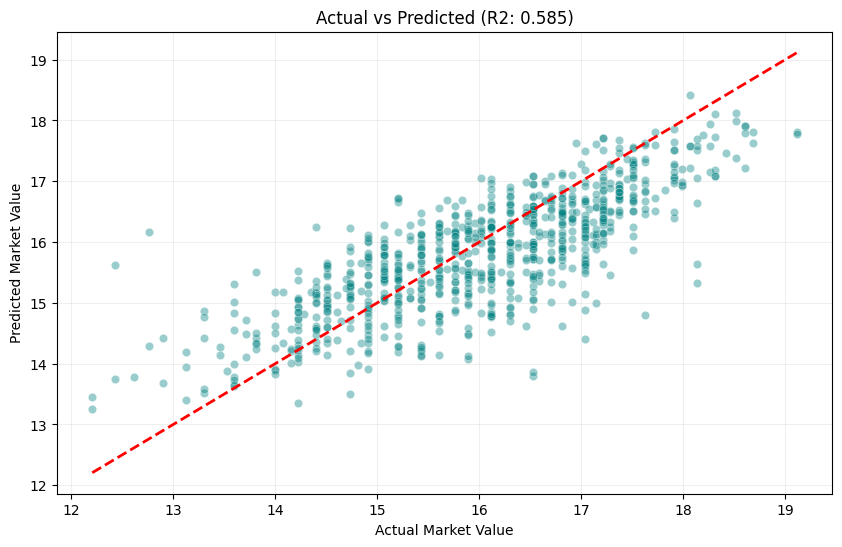

In [5]:
plot_result(y_pred, y_test)

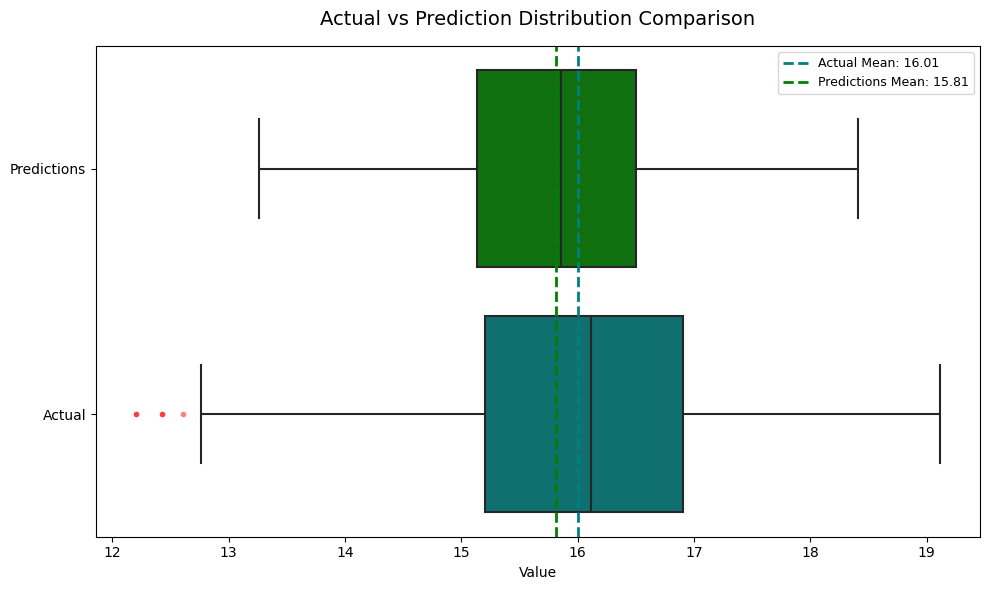

In [6]:
plot_comparison_boxplot(y_pred, y_test)

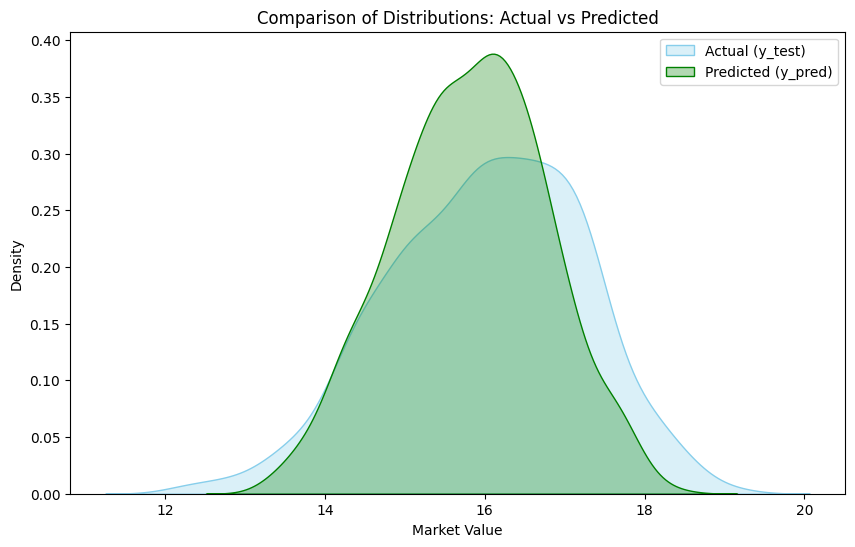

In [7]:
plot_distribution_compare(y_pred, y_test)

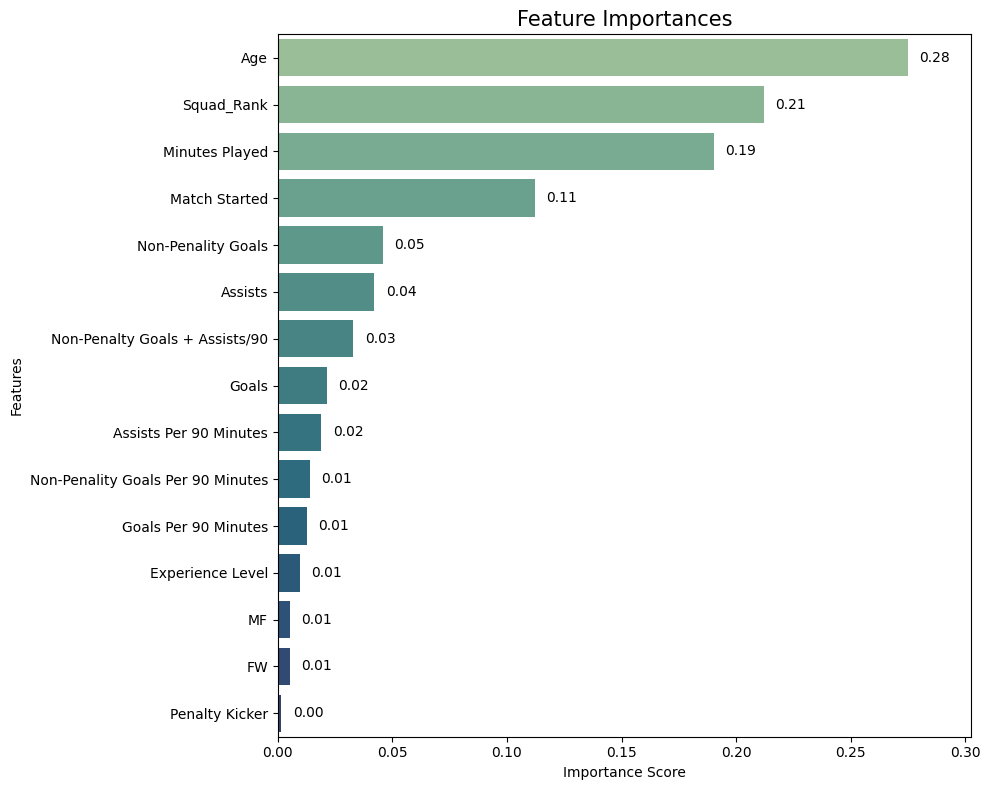

In [8]:
plot_rf_importance(rfr, X_train)

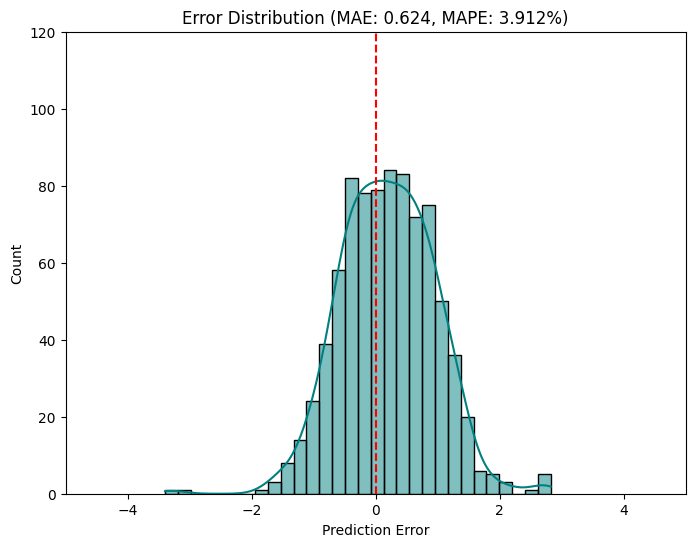

In [9]:
plot_error_distribution(y_pred, y_test)

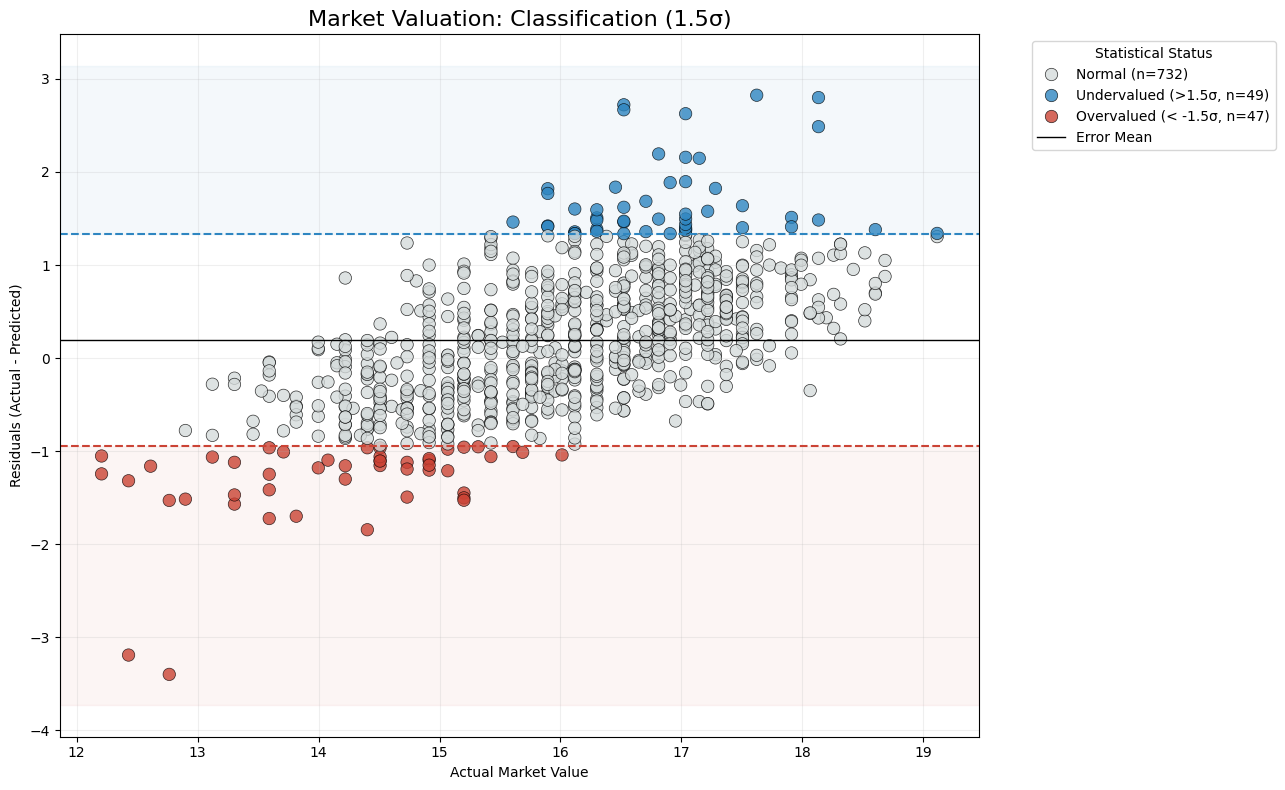

In [10]:
plot_residual(y_pred, y_test)

In [11]:
xgbModel = joblib.load('xgboost.joblib')

In [12]:
xgb_prediction = xgbModel.predict(X_test)

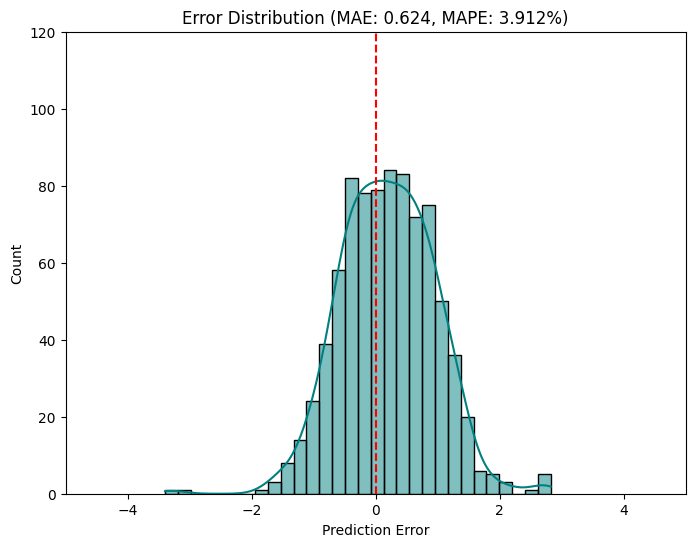

In [13]:
plot_error_distribution(y_pred, y_test)

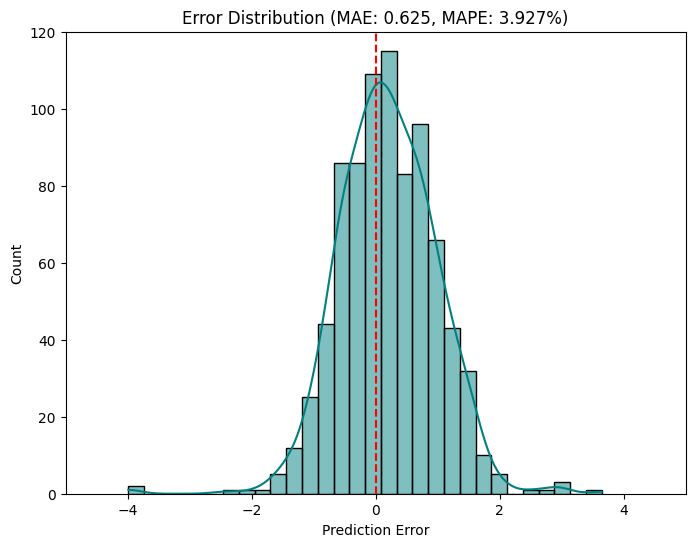

In [14]:
plot_error_distribution(xgb_prediction, y_test)